
# 用 Policy Iteration 学会 Gridworld —— 从零开始的强化学习入门 Notebook

> 适用对象：一年级下本科生（无强化学习基础亦可）  
> 目标：理解 **MDP**、**策略评估**、**策略改进**，并用 **策略迭代（Policy Iteration）** 在 4×4 Gridworld 上求最优策略。

---

## 你将学到什么？
- 强化学习（Reinforcement Learning, RL）在做什么
- **MDP** 的 5 个要素：状态 $\mathcal{S}$、动作 $\mathcal{A}$、转移概率 $P$、奖励 $R$、折扣因子 $\gamma$
- **策略（policy）**、**状态价值函数** $V^\pi$、**动作价值函数** $Q^\pi$
- **贝尔曼方程（Bellman Equations）**
- **策略评估（Policy Evaluation）** 与 **策略改进（Policy Improvement）**
- **策略迭代（Policy Iteration）**：评估-改进交替直到收敛
- 用代码在 Gridworld 上一步一步可视化结果



## 1. 强化学习是什么？
- RL 的主体叫 **智能体（Agent）**，与 **环境（Environment）** 交互。
- 每一步，智能体在状态 $s$ 下选择动作 $a$，环境给出下一个状态 $s'$ 和奖励（回报）$r$。
- 智能体的目标是使 **长期累积回报** 最大化。

> 直觉：像走迷宫。每走一步都会有代价（-1），到达终点结束并希望总损失最小（或总回报最大）。



## 2. 马尔可夫决策过程（MDP）
一个 MDP 由 5 个元素组成：
- **状态集合** $\mathcal{S}$：所有可能的位置或情形。
- **动作集合** $\mathcal{A}$：在任一状态下可做的选择。
- **转移概率** $P(s' \mid s,a)$：执行动作 $a$ 后从 $s$ 到达 $s'$ 的概率。
- **奖励函数** $R(s,a,s')$：这次转移带来的即时奖励（可以是负数，例如每走一步给 -1）。
- **折扣因子** $\gamma \in [0,1]$：越接近 1 越重视长期；若为 0 只在意眼前。

**策略（policy）** $\pi(a\mid s)$：告诉我们在状态 $s$ 下以多大概率选择动作 $a$。

**价值函数**：  
- **状态价值**：
  $V^\pi(s) \;=\; \mathbb{E}_{\pi}\!\left[\sum_{t=0}^{\infty} \gamma^t r_{t+1} \;\middle|\; s_0=s\right].$
- **动作价值**：
  $Q^\pi(s,a) \;=\; \mathbb{E}_{\pi}\!\left[\sum_{t=0}^{\infty} \gamma^t r_{t+1} \;\middle|\; s_0=s,\, a_0=a\right].$

**贝尔曼方程（对任意策略）**：
$V^\pi(s) \;=\; \sum_{a} \pi(a\mid s) \sum_{s'} P(s'\mid s,a)\,\big[ R(s,a,s') + \gamma \, V^\pi(s') \big].$

**最优性方程**（当我们总是选最优动作时）：
$V^{*}(s) \;=\; \max_{a} \sum_{s'} P(s'\mid s,a)\,\big[ R(s,a,s') + \gamma \, V^{*}(s') \big].$

> **策略迭代**的核心思想：  
> 1. **策略评估**：在当前策略 $\pi$ 下，求解 $V^\pi$（数值迭代逼近即可）。  
> 2. **策略改进**：用 $Q^\pi$ 做贪心更新，得到更好的策略 $\pi'$。  
> 3. 重复 1–2，直到策略不再改变（收敛到最优策略 $\pi^{*}$）。



## 3. 我们要解决的 Gridworld
- 一个 **4×4** 的网格世界：共 16 个格子。
- 左上角 **(0,0)** 和右下角 **(3,3)** 是**终止状态（Terminal）**。
- 每移动一步都会得到 **-1** 的奖励；到达终止状态后不再移动（留在原地，奖励 0）。
- 动作集合：**上、右、下、左**（越界则原地不动）。
- 我们设折扣因子 $\gamma = 1.0$（任务会在终止状态结束，因此仍可收敛）。

**可视化约定**  
- 策略用箭头表示：↑、→、↓、←。出现多个箭头表示多个最优动作并列。
- 价值函数用网格中的数字表示（越接近 0 越好，因为我们每步 -1）。


In [19]:

# == 代码准备 ==
from __future__ import annotations
from dataclasses import dataclass
from typing import Tuple, Dict, List
import numpy as np
import matplotlib.pyplot as plt

# 为了更易读的打印
def grid_to_str(grid: np.ndarray, fmt="{:6.1f}") -> str:
    """把 2D 数组打印成整齐的文本表格。"""
    rows = []
    for r in grid:
        rows.append(" ".join(fmt.format(x) for x in r))
    return "\n".join(rows)

arrow_map = {0: "↑", 1: "→", 2: "↓", 3: "←"}



### 3.1 环境实现（Environment）
我们用一个简单的类来描述 Gridworld：
- `n_rows, n_cols`：网格尺寸
- `terminals`：终止状态集合
- `step(s, a)`：从状态 `s` 执行动作 `a` 的转移函数，返回 `(s', r)`
- `actions`：四个离散动作（上=0、右=1、下=2、左=3）


In [20]:

@dataclass
class Gridworld:
    n_rows: int = 4
    n_cols: int = 4
    step_reward: float = -1.0           # 每走一步的奖励（代价）
    terminals: Tuple[Tuple[int, int], ...] =  ((0, 0), (3, 3)) # 终止状态 ((0, 0), (3, 3))
    
    def __post_init__(self):
        self.n_states = self.n_rows * self.n_cols
        self.actions = [0, 1, 2, 3]  # 上右下左
        self.action_names = {0: "UP", 1: "RIGHT", 2: "DOWN", 3: "LEFT"}
    
    def in_bounds(self, r: int, c: int) -> bool:
        return 0 <= r < self.n_rows and 0 <= c < self.n_cols
    
    def to_state(self, rc: Tuple[int, int]) -> int:
        r, c = rc
        return r * self.n_cols + c
    
    def to_rc(self, s: int) -> Tuple[int, int]:
        return divmod(s, self.n_cols)
    
    def is_terminal(self, rc: Tuple[int, int]) -> bool:
        return rc in self.terminals
    
    def step(self, rc: Tuple[int, int], a: int) -> Tuple[Tuple[int, int], float]:
        """确定性转移：超出边界则留在原地。终止状态原地不动且奖励 0。"""
        if self.is_terminal(rc):
            # 终止状态：停在原地，奖励为 0
            return rc, 0.0
        
        r, c = rc
        if a == 0:    # UP
            nr, nc = r - 1, c
        elif a == 1:  # RIGHT
            nr, nc = r, c + 1
        elif a == 2:  # DOWN
            nr, nc = r + 1, c
        else:         # LEFT
            nr, nc = r, c - 1
        
        # 越界则原地不动
        if not self.in_bounds(nr, nc):
            nr, nc = r, c
        
        # 到达终止状态后，下次再 step 就会得到 0；但这次的步长奖励仍是 step_reward
        reward = self.step_reward
        return (nr, nc), reward



### 3.2 策略与可视化辅助函数
- 策略用形状为 `(n_rows, n_cols, 4)` 的数组表示 **每个状态对 4 个动作的概率分布**。
- 终止状态的策略我们设为全 0（不会再行动）。


In [21]:

def init_random_policy(env: Gridworld) -> np.ndarray:
    """
    初始化均匀随机策略
    
    参数:
        env: Gridworld环境对象
        
    返回:
        策略数组，形状为 (n_rows, n_cols, 4)
        每个元素表示在对应状态下选择对应动作的概率
        
    注意:
        - 终止状态的策略设为全0（不会再行动）
        - 非终止状态对4个动作等概率选择（0.25）
    """
    # 初始化策略数组，全为0
    policy = np.zeros((env.n_rows, env.n_cols, 4), dtype=float)
    
    # 遍历所有状态
    for r in range(env.n_rows):
        for c in range(env.n_cols):
            if not env.is_terminal((r, c)):  # 非终止状态
                policy[r, c, :] = 0.25  # 对4个动作等概率选择
    
    return policy

def render_policy(policy: np.ndarray, env: Gridworld) -> List[List[str]]:
    """
    将策略渲染成箭头字符串网格，用于可视化
    
    参数:
        policy: 策略数组，形状为 (n_rows, n_cols, 4)
        env: Gridworld环境对象
        
    返回:
        字符串网格，每个元素是箭头字符串
        
    注意:
        - 终止状态显示为"■"
        - 每个状态显示概率最大的动作对应的箭头
        - 如果有多个动作概率相同，显示多个箭头
    """
    # 初始化字符串网格
    grid = [["" for _ in range(env.n_cols)] for _ in range(env.n_rows)]
    
    for r in range(env.n_rows):
        for c in range(env.n_cols):
            if env.is_terminal((r, c)):
                grid[r][c] = "■"  # 终止状态用方块表示
            else:
                probs = policy[r, c]  # 当前状态的动作概率
                
                # 找到概率最大的动作（可能有并列）
                maxp = probs.max()
                arrows = []
                for a, p in enumerate(probs):
                    if abs(p - maxp) < 1e-12:  # 数值精度范围内相等
                        arrows.append(arrow_map[a])
                
                grid[r][c] = "".join(arrows)  # 连接所有最优动作的箭头
    
    return grid

def print_arrow_grid(arrow_grid: List[List[str]]):
    """
    打印箭头网格
    
    参数:
        arrow_grid: 箭头字符串网格
    """
    for row in arrow_grid:
        # 每个单元格居中显示，宽度为4
        print(" ".join(f"{cell:^4}" for cell in row))

def values_to_grid(V: np.ndarray, env: Gridworld) -> np.ndarray:
    """
    将一维价值函数转换为2D网格格式
    
    参数:
        V: 一维价值函数数组，长度为n_states
        env: Gridworld环境对象
        
    返回:
        2D价值函数网格，形状为 (n_rows, n_cols)
    """
    return V.reshape(env.n_rows, env.n_cols)



## 4. 策略评估（Policy Evaluation）
给定一个策略 $\pi$，我们想要计算 $V^\pi$。直接解线性方程组可以，但更直观的是**迭代法**：

**迭代策略评估（同步更新）**
1. 初始化 $V(s)=0$
2. 重复进行“sweep”（全表扫描）：
   $V_{\text{new}}(s) \leftarrow \sum_{a} \pi(a\mid s) \sum_{s'} P(s'\mid s,a)\big[ R(s,a,s') + \gamma V(s') \big]$
   \]$
3. 直到所有状态的变化都很小（小于阈值 $\theta$）。

下面的实现会：
- 返回最终的 $V$
- 为了教学演示，还会把前几次 sweep 的**中间结果**保存下来，便于逐步可视化。


In [22]:

def policy_evaluation(env: Gridworld, policy: np.ndarray, gamma=1.0, theta=1e-8,
                      record_first_n_sweeps: int = 5):
    """
    策略评估：在给定策略下计算状态价值函数V(s)
    
    算法原理：
    使用贝尔曼方程的迭代求解方法：
    V(s) = Σ_a π(a|s) Σ_s' P(s'|s,a)[R(s,a,s') + γV(s')]
    
    参数:
        env: Gridworld环境对象
        policy: 策略数组，形状为 (n_rows, n_cols, 4)
        gamma: 折扣因子，控制未来奖励的重要性
        theta: 收敛阈值，当价值函数变化小于此值时停止迭代
        record_first_n_sweeps: 记录前N次迭代的快照，用于可视化
        
    返回:
        V: 最终收敛后的价值函数（一维向量，长度n_states）
        snapshots: 前N次迭代的快照列表，用于教学展示
    """
    # 初始化价值函数为0
    V = np.zeros(env.n_states, dtype=float)
    snapshots = []  # 存储迭代快照
    
    sweep = 0  # 迭代次数计数器
    
    while True:
        delta = 0.0  # 本轮迭代的最大变化量
        V_new = V.copy()  # 创建新价值函数的副本
        
        # 遍历所有状态进行同步更新
        for s in range(env.n_states):
            r, c = env.to_rc(s)  # 将状态编号转换为坐标
            
            # 终止状态的价值固定为0
            if env.is_terminal((r, c)):
                V_new[s] = 0.0
                continue
            
            # 计算当前状态的价值
            v = 0.0
            for a, pi in enumerate(policy[r, c]):  # 遍历所有动作
                if pi == 0.0:  # 如果动作概率为0，跳过
                    continue
                
                # 执行动作，获取新状态和奖励
                (nr, nc), reward = env.step((r, c), a)
                s_next = env.to_state((nr, nc))
                
                # 累加期望价值：π(a|s) * [R + γV(s')]
                v += pi * (reward + gamma * V[s_next])
            
            V_new[s] = v  # 更新状态价值
        
        # 计算本轮迭代的最大变化量
        delta = np.max(np.abs(V_new - V))
        V = V_new  # 更新价值函数
        
        # 记录前几次迭代的快照
        if sweep < record_first_n_sweeps:
            snapshots.append(V.copy())
        
        sweep += 1
        
        # 检查是否收敛
        if delta < theta:
            break
    
    return V, snapshots



## 5. 策略改进（Policy Improvement）
有了 $V^\pi$，我们可以计算每个动作的“好坏”（动作价值）：
$$
Q^\pi(s,a) = \sum_{s'} P(s'\mid s,a)\big[ R(s,a,s') + \gamma V^\pi(s') \big].
$$
然后在每个状态上选择能让 $Q$ 最大的动作（或把最优动作的概率平均摊开）。这一步叫**策略贪心改进**。


In [23]:

def greedy_policy_improvement(env: Gridworld, V: np.ndarray, gamma=1.0) -> np.ndarray:
    """
    策略改进：根据价值函数计算贪心策略
    
    算法原理：
    对每个状态，选择使Q(s,a)最大的动作：
    Q(s,a) = R(s,a,s') + γV(s')
    π'(a|s) = 1 if a = argmax_a Q(s,a), 0 otherwise
    
    参数:
        env: Gridworld环境对象
        V: 当前价值函数
        gamma: 折扣因子
        
    返回:
        新的贪心策略，形状为 (n_rows, n_cols, 4)
    """
    # 初始化新策略
    policy = np.zeros((env.n_rows, env.n_cols, 4), dtype=float)
    
    for r in range(env.n_rows):
        for c in range(env.n_cols):
            # 终止状态不需要策略
            if env.is_terminal((r, c)):
                continue
            
            # 计算每个动作的Q值
            q_values = []
            for a in env.actions:
                (nr, nc), reward = env.step((r, c), a)
                s_next = env.to_state((nr, nc))
                q = reward + gamma * V[s_next]  # Q(s,a) = R + γV(s')
                q_values.append(q)
            
            q_values = np.array(q_values)
            
            # 找到Q值最大的动作（可能有并列）
            max_q = np.max(q_values)
            best_actions = np.where(np.abs(q_values - max_q) < 1e-12)[0]
            
            # 将概率平均分配给所有最优动作
            policy[r, c, best_actions] = 1.0 / len(best_actions)
    
    return policy



## 6. 策略迭代（Policy Iteration）
我们交替进行：  
1. **策略评估**：在当前策略 $\pi$ 下求 $V^\pi$；  
2. **策略改进**：把 $\pi$ 替换为对 $V^\pi$ 贪心的策略。

若一次改进后策略没有变化，则已经到达**最优策略**。

下面的函数会把每次迭代的**策略网格**与**价值快照**都记录下来，便于一步步展示。


In [24]:

def policy_iteration(env: Gridworld, gamma=1.0, theta=1e-8, max_iterations=100):
    """
    策略迭代算法：交替进行策略评估和策略改进直到收敛
    
    算法流程：
    1. 初始化随机策略
    2. 重复直到策略收敛：
       a. 策略评估：计算当前策略下的价值函数V^π
       b. 策略改进：根据V^π计算贪心策略π'
       c. 如果π' = π，则停止（已找到最优策略）
    
    参数:
        env: Gridworld环境对象
        gamma: 折扣因子
        theta: 策略评估的收敛阈值
        max_iterations: 最大迭代次数，防止无限循环
        
    返回:
        optimal_V: 最优价值函数V*
        optimal_policy: 最优策略π*
        history: 每次迭代的历史记录，用于教学展示
    """
    # 初始化随机策略
    policy = init_random_policy(env)
    history = []  # 存储迭代历史
    
    for it in range(max_iterations):
        print(f"开始第 {it} 次迭代...")
        
        # 步骤1：策略评估
        # 在当前策略下计算价值函数
        V, snapshots = policy_evaluation(env, policy, gamma=gamma, theta=theta,
                                         record_first_n_sweeps=5)
        
        # 步骤2：策略改进
        # 根据价值函数计算贪心策略
        new_policy = greedy_policy_improvement(env, V, gamma=gamma)
        
        # 记录本次迭代的信息
        history.append({
            'iter': it,                    # 迭代次数
            'policy': policy.copy(),        # 本次迭代使用的策略
            'V_eval_snapshots': snapshots,  # 策略评估的中间快照
            'V_after_eval': V.copy()        # 策略评估后的价值函数
        })
        
        # 检查策略是否收敛
        if np.allclose(new_policy, policy):
            print(f"策略在第 {it} 次迭代后收敛！")
            break
        
        # 更新策略
        policy = new_policy
    
    # 返回最终结果
    optimal_V = V
    optimal_policy = policy
    return optimal_V, optimal_policy, history



## 7. 动手：运行策略迭代，并逐步可视化
我们会：
1. 先打印**初始随机策略**；
2. 展示**前几次 sweep 的价值函数**（帮助理解“策略评估”是怎样逐步收敛的）；
3. 再显示**每次策略改进后的新策略**；
4. 直到策略不再改变（收敛）。


In [25]:

# 创建环境并设置参数
env = Gridworld()
gamma = 0.9  # 折扣因子

print("=" * 60)
print("Gridworld策略迭代算法演示")
print("=" * 60)
print(f"环境设置：{env.n_rows}×{env.n_cols}网格")
print(f"终止状态：{env.terminals}")
print(f"步长奖励：{env.step_reward}")
print(f"折扣因子：{gamma}")

# 执行策略迭代算法
print("\n开始策略迭代...")
V_star, pi_star, history = policy_iteration(env, gamma=gamma, theta=1e-10)

print("\n" + "=" * 60)
print("最终结果")
print("=" * 60)

print("\n最优价值函数 V*:")
V_grid = values_to_grid(V_star, env)
print(grid_to_str(V_grid))

print("\n最优策略 π*:")
policy_grid = render_policy(pi_star, env)
print_arrow_grid(policy_grid)

# 显示详细的迭代过程
print("\n" + "=" * 60)
print("详细迭代过程展示")
print("=" * 60)

print("=== 初始随机策略（迭代 0 之前） ===")
initial_policy_grid = render_policy(history[0]['policy'], env)
print_arrow_grid(initial_policy_grid)

for rec in history:
    it = rec['iter']
    print(f"\n=== 迭代 {it}：策略评估的前几次 sweep 的 V(s) 快照 ===")
    for k, V_snap in enumerate(rec['V_eval_snapshots']):
        print(f"  k = {k}")
        print(grid_to_str(values_to_grid(V_snap, env)))
        print()
    
    print(f"--- 迭代 {it}：评估收敛后的 V(s) ---")
    print(grid_to_str(values_to_grid(rec['V_after_eval'], env)))
    
    # 策略改进后的新策略（如果有下一条记录就能看到变化）
    if it + 1 < len(history):
        print(f"--- 迭代 {it}：策略改进后的策略（作为下一次评估的起点） ---")
        improved_grid = render_policy(history[it+1]['policy'], env)
        print_arrow_grid(improved_grid)

print("\n=== 最终最优价值函数 V* ===")
print(grid_to_str(values_to_grid(V_star, env)))

print("\n=== 最终最优策略 π* ===")
print_arrow_grid(render_policy(pi_star, env))


Gridworld策略迭代算法演示
环境设置：4×4网格
终止状态：((0, 0), (3, 3))
步长奖励：-1.0
折扣因子：0.9

开始策略迭代...
开始第 0 次迭代...
开始第 1 次迭代...
开始第 2 次迭代...
策略在第 2 次迭代后收敛！

最终结果

最优价值函数 V*:
   0.0   -1.0   -1.9   -2.7
  -1.0   -1.9   -2.7   -1.9
  -1.9   -2.7   -1.9   -1.0
  -2.7   -1.9   -1.0    0.0

最优策略 π*:
 ■    ←    ←    ↓← 
 ↑    ↑←  ↑→↓←  ↓  
 ↑   ↑→↓←  →↓   ↓  
 ↑→   →    →    ■  

详细迭代过程展示
=== 初始随机策略（迭代 0 之前） ===
 ■   ↑→↓← ↑→↓← ↑→↓←
↑→↓← ↑→↓← ↑→↓← ↑→↓←
↑→↓← ↑→↓← ↑→↓← ↑→↓←
↑→↓← ↑→↓← ↑→↓←  ■  

=== 迭代 0：策略评估的前几次 sweep 的 V(s) 快照 ===
  k = 0
   0.0   -1.0   -1.0   -1.0
  -1.0   -1.0   -1.0   -1.0
  -1.0   -1.0   -1.0   -1.0
  -1.0   -1.0   -1.0    0.0

  k = 1
   0.0   -1.7   -1.9   -1.9
  -1.7   -1.9   -1.9   -1.9
  -1.9   -1.9   -1.9   -1.7
  -1.9   -1.9   -1.7    0.0

  k = 2
   0.0   -2.2   -2.7   -2.7
  -2.2   -2.6   -2.7   -2.7
  -2.7   -2.7   -2.6   -2.2
  -2.7   -2.7   -2.2    0.0

  k = 3
   0.0   -2.7   -3.3   -3.4
  -2.7   -3.2   -3.4   -3.3
  -3.3   -3.4   -3.2   -2.7
  -3.4   -3.3   -2.7    0.0

  k = 4


## 汇总：每次迭代的策略与最终评估的价值函数

下面将把每次迭代得到的策略（作为该次评估的起点）与该次评估收敛后的价值函数 V(s) 一并打印，便于对照查看。


In [17]:
# 汇总打印每次迭代的策略与最终评估的 V(s)
for rec in history:
    it = rec['iter']
    print(f"\n================ 迭代 {it} =================")
    print("-- 该次迭代使用的策略（作为评估起点） --")
    print_arrow_grid(render_policy(rec['policy'], env))
    print("\n-- 该次迭代评估收敛后的 V(s) --")
    print(grid_to_str(values_to_grid(rec['V_after_eval'], env)))

print("\n============= 汇总结束 =============\n")



================ 迭代 0 =================
-- 该次迭代使用的策略（作为评估起点） --
 ■   ↑→↓← ↑→↓← ↑→↓←
↑→↓← ↑→↓← ↑→↓← ↑→↓←
↑→↓← ↑→↓← ↑→↓← ↑→↓←
↑→↓← ↑→↓← ↑→↓←  ■  

-- 该次迭代评估收敛后的 V(s) --
   0.0   -5.3   -7.1   -7.7
  -5.3   -6.6   -7.2   -7.1
  -7.1   -7.2   -6.6   -5.3
  -7.7   -7.1   -5.3    0.0

================ 迭代 1 =================
-- 该次迭代使用的策略（作为评估起点） --
 ■    ←    ←    ↓← 
 ↑    ↑←   ↓←   ↓  
 ↑    ↑→   →↓   ↓  
 ↑→   →    →    ■  

-- 该次迭代评估收敛后的 V(s) --
   0.0   -1.0   -1.9   -2.7
  -1.0   -1.9   -2.7   -1.9
  -1.9   -2.7   -1.9   -1.0
  -2.7   -1.9   -1.0    0.0

================ 迭代 2 =================
-- 该次迭代使用的策略（作为评估起点） --
 ■    ←    ←    ↓← 
 ↑    ↑←  ↑→↓←  ↓  
 ↑   ↑→↓←  →↓   ↓  
 ↑→   →    →    ■  

-- 该次迭代评估收敛后的 V(s) --
   0.0   -1.0   -1.9   -2.7
  -1.0   -1.9   -2.7   -1.9
  -1.9   -2.7   -1.9   -1.0
  -2.7   -1.9   -1.0    0.0

============= 汇总结束 =============




### 7.1 可选：把价值函数画成热力图（仅作直观展示）
> 我们使用 `matplotlib` 的默认配色，不手动指定颜色。图像数目控制为**一个图一个绘制**。


/tmp/ipykernel_2667311/4043486292.py:19: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2667311/4043486292.py:19: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2667311/4043486292.py:19: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2667311/4043486292.py:19: UserWarning: Glyph 32456 (\N{CJK UNIFIED IDEOGRAPH-7EC8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2667311/4043486292.py:19: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2667311/4043486292.py:19: UserWarning: Glyph 36234 (\N{CJK UNIFIED IDEOGRAPH-8D8A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2667311/4043486292.py:19: UserWarning: Glyph 25509 (\N{CJK UN

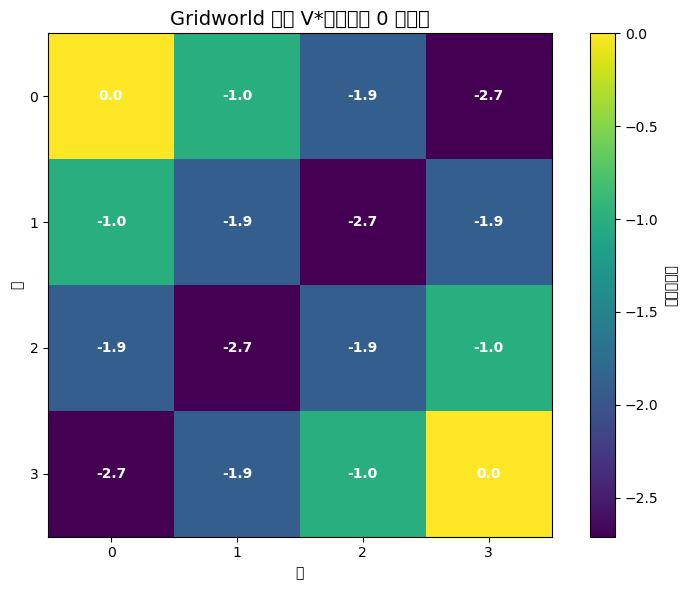

In [18]:

# 创建价值函数的热力图可视化
V_grid = values_to_grid(V_star, env)

plt.figure(figsize=(8, 6))
plt.title("Gridworld 最终 V*（越接近 0 越好）", fontsize=14)
im = plt.imshow(V_grid, cmap='viridis')  # 使用viridis配色方案
plt.colorbar(im, label='价值函数值')
plt.xticks(range(env.n_cols))
plt.yticks(range(env.n_rows))
plt.xlabel('列')
plt.ylabel('行')

# 在网格上显示数值
for i in range(env.n_rows):
    for j in range(env.n_cols):
        plt.text(j, i, f'{V_grid[i, j]:.1f}', 
                ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()



## 8. 思考与练习（推荐当堂完成）
1. **把折扣因子改成 $\gamma = 0.9$**，观察最优策略是否变化？价值函数的量级如何变化？为什么？
2. **把步长奖励从 -1 改为 -0.1**。理论上这会让“走远路”的代价变小还是变大？最优策略会有变化吗？
3. 把网格改为 **5×5**，终止状态依旧在左上和右下。尝试重新跑一遍策略迭代。
4. 尝试在某个格子设置**墙（不可进入）**或**陷阱（进入就结束并给大负奖励）**，看看策略会如何改变。
5. 思考：如果转移是**随机的**（例如 0.8 概率按所选方向走，0.2 概率随机走其他方向），我们的评估与改进公式需作何修改？

> **提示**：所有改变都只需要修改环境或奖励，其余算法几乎不变。这就是用 MDP 建模的威力。



## 附录：贝尔曼方程的直观理解
我们在状态 $s$ 的价值，可以看成**这一步的即时奖励**加上**下一个状态的价值**（乘上折扣）。  
把“下一步再套一次这个关系”，就得到一个**自洽的方程**。正因为这个自洽性，我们可以通过不断“全表扫描”来逼近真实解。

- 当策略固定时，我们就得到 **策略评估方程**（线性）。
- 当我们在每个状态上选择让右侧期望最大的动作，就得到 **最优性方程**（非线性）。
- **策略迭代**把两者结合：固定策略时解线性方程；解完后再贪心地改策略；重复直到策略稳定。
